ANÁLISIS DATOS CAMPEONATO DE HALTEROFILIA EN ESPAÑA

FASE 1: Análisis con datos proporcionados (2019-2020)

1. Importación y exploración inicial

Dado que los datos no están disponibles a través de los links del PDF enviado, he hecho webscraping directamente en la página correspondiente de Wikipedia para obtener los datos de 2019 y 2020

In [1]:
# Importamos las librerías necesarias para el análisis

import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Obtención de los datos del Campeonato de Halterofilia de 2019

url = "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2019"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)
tablas = pd.read_html(response.text, header=0) #lee todas las tablas de la web
print(f"Se encontraron {len(tablas)} tablas en la página.") #hay 10 tablas en esa página. Hemos de encontrar las que nos interesan (medallistas)
masculino2019 = tablas[5]
femenino2019 = tablas[6]

Se encontraron 10 tablas en la página.


C:\Users\amour1\AppData\Local\Temp\ipykernel_20356\1115005384.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tablas = pd.read_html(response.text, header=0) #lee todas las tablas de la web


In [3]:
masculino2019.head() #ok

,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,55 kg (06.04),Mirco Scarantino Italia 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turquía 112 + 135 = 247[n 1]​
1,61 kg (07.04),Henadz Laptseu Bielorrusia 133 + 153 = 286,Bünyamin Sezer Turquía 132 + 151 = 283,Ferdi Hardal Turquía 127 + 155 = 282
2,67 kg (08.04),Bernardin Matam Francia 137 + 175 = 312,Simon Brandhuber Alemania 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Bielorrusia 153 + 182 = 335
4,81 kg (10.04),Antonino Pizzolato Italia 155 + 201 = 356,Piotr Asayonak Bielorrusia 159 + 196 = 355,Ritvars Suharevs Letonia 162 + 192 = 354


In [4]:
femenino2019.head() #ok

,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,45 kg (06.04),Şaziye Erdoğan Turquía 75 + 88 = 163[n 1]​,Ivana Petrova Bulgaria 69 + 89 = 158[n 1]​,Yuliya Asayonak Bielorrusia 69 + 81 = 150[n 1]​
1,49 kg (06.04),Elena Andrieș Rumania 87 + 103 = 190,Kristina Sobol Rusia 85 + 95 = 180,Giorgia Russo Italia 75 + 103 = 178
2,55 kg (07.04),Joanna Łochowska Polonia 87 + 112 = 199,Svetlana Yershova Rusia 90 + 108 = 198,Kristina Novitskaya Rusia 85 + 105 = 190
3,59 kg (08.04),Rebeka Koha Letonia 101 + 120 = 221,Tatiana Aleyeva Rusia 94 + 120 = 214,Alexandra Kozlova Rusia 96 + 117 = 213
4,64 kg (09.04),Loredana Toma Rumania 111 + 128 = 239,Irina Lepșa Rumania 102 + 127 = 229,Zoe Smith Reino Unido 96 + 128 = 224


In [5]:
#conozcamos algo más el contenido de las tablas (missing data, ver si coinciden los campos entre ellas, etc.)
print(masculino2019.info())
print(femenino2019.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Evento      10 non-null     object
 1   Unnamed: 1  10 non-null     object
 2   Unnamed: 2  10 non-null     object
 3   Unnamed: 3  10 non-null     object
dtypes: object(4)
memory usage: 452.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Evento      10 non-null     object
 1   Unnamed: 1  10 non-null     object
 2   Unnamed: 2  10 non-null     object
 3   Unnamed: 3  10 non-null     object
dtypes: object(4)
memory usage: 452.0+ bytes
None


2. Transformación de datos
Combina los datos en un único DataFrame y ajusta su formato para incluir las siguientes columnas: Eventos, Año, Género, Medalla (Oro, Plata, Bronce) y Atleta.

In [6]:
#añadimos género
masculino2019.insert(loc=1, column="Género", value="Masculino")  
femenino2019.insert(loc=1, column="Género", value="Femenino")  

In [7]:
#compilamos ambas tablas para tener el total de medallistas de 2019 en una sola tabla
total2019=pd.concat([masculino2019, femenino2019], axis=0)
total2019

,Evento,Género,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,55 kg (06.04),Masculino,Mirco Scarantino Italia 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turquía 112 + 135 = 247[n 1]​
1,61 kg (07.04),Masculino,Henadz Laptseu Bielorrusia 133 + 153 = 286,Bünyamin Sezer Turquía 132 + 151 = 283,Ferdi Hardal Turquía 127 + 155 = 282
2,67 kg (08.04),Masculino,Bernardin Matam Francia 137 + 175 = 312,Simon Brandhuber Alemania 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308
3,73 kg (09.04),Masculino,Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Bielorrusia 153 + 182 = 335
4,81 kg (10.04),Masculino,Antonino Pizzolato Italia 155 + 201 = 356,Piotr Asayonak Bielorrusia 159 + 196 = 355,Ritvars Suharevs Letonia 162 + 192 = 354
5,89 kg (11.04),Masculino,Hakob Mkrtchian Armenia 164 + 207 = 371,Revaz Davitadze Georgia 170 + 200 = 370,Davit Hovhannisian Armenia 165 + 195 = 360
6,96 kg (12.04),Masculino,Yauheni Tsijantsou Bielorrusia 178 + 222 = 400,Yegor Klimonov Rusia 168 + 210 = 378,Anton Pliesnoi Georgia 173 + 204 = 377
7,102 kg (13.04),Masculino,Dmytro Chumak Ucrania 175 + 216 = 391,Samvel Gasparian Armenia 168 + 209 = 377,Vadzim Straltsou Bielorrusia 170 + 206 = 376
8,109 kg (13.04),Masculino,Simon Martirosian Armenia 192 + 235 = 427,Andrei Aramnau Bielorrusia 190 + 221 = 411,Rodion Bochkov Rusia 192 + 218 = 410
9,+109 kg (13.04),Masculino,Lasha Talajadze Georgia 218 + 260 = 478,Irakli Turmanidze Georgia 206 + 241 = 447,Ruben Alexanian Armenia 195 + 245 = 440


In [8]:
#Añadimos año
total2019.insert(loc=1, column="Año", value="2019")  

In [9]:
#añadimos medalla. Nota: cada columna de Unnamed pertenece al tipo de medalla (oro, plata, bronce) 

total2019.insert(loc=1, column="Medalla Oro", value="Oro")  
total2019.insert(loc=3, column="Medalla Plata", value="Plata")  
total2019.insert(loc=5, column="Medalla Bronce", value="Bronce")  

In [10]:
#ordenemos la tabla que el tipo de medalla no esté en 3 columnas, si no en 1
total2019_orden = pd.DataFrame({
    "Evento": total2019["Evento"].tolist() * 3,
    "Género": total2019["Género"].tolist() * 3,
    "Año": total2019["Año"].tolist() * 3,
    "Atleta": (
        total2019["Unnamed: 1"].tolist()
        + total2019["Unnamed: 2"].tolist()
        + total2019["Unnamed: 3"].tolist()
      ),
    "Medalla": (
        total2019["Medalla Oro"].tolist()
        + total2019["Medalla Plata"].tolist()
        + total2019["Medalla Bronce"].tolist()
    )
})

In [11]:
#limpieza de valores no necesarios (p. ej. [n 1])
total2019_orden["Evento"] = total2019_orden["Evento"].str.replace("[n 2]", "", regex=False)
total2019_orden["Atleta"] = total2019_orden["Atleta"].str.replace("[n 1]", "", regex=False)
total2019_orden["Atleta"] = total2019_orden["Atleta"].str.replace("[1]", "", regex=False)
total2019_orden["Atleta"] = total2019_orden["Atleta"].str.replace("[2]", "", regex=False)
total2019_orden #ok, 60 observaciones

,Evento,Género,Año,Atleta,Medalla
0,55 kg (06.04),Masculino,2019,Mirco Scarantino Italia 116 + 145 = 261​,Oro
1,61 kg (07.04),Masculino,2019,Henadz Laptseu Bielorrusia 133 + 153 = 286,Oro
2,67 kg (08.04),Masculino,2019,Bernardin Matam Francia 137 + 175 = 312,Oro
3,73 kg (09.04),Masculino,2019,Bozhidar Andreev Bulgaria 153 + 192 = 345,Oro
4,81 kg (10.04),Masculino,2019,Antonino Pizzolato Italia 155 + 201 = 356,Oro
5,89 kg (11.04),Masculino,2019,Hakob Mkrtchian Armenia 164 + 207 = 371,Oro
6,96 kg (12.04),Masculino,2019,Yauheni Tsijantsou Bielorrusia 178 + 222 = 400,Oro
7,102 kg (13.04),Masculino,2019,Dmytro Chumak Ucrania 175 + 216 = 391,Oro
8,109 kg (13.04),Masculino,2019,Simon Martirosian Armenia 192 + 235 = 427,Oro
9,+109 kg (13.04),Masculino,2019,Lasha Talajadze Georgia 218 + 260 = 478,Oro


In [12]:
#la variable Atleta tiene varias observaciones, no sólo el nombre del atleta. Quedarnos sólo con nombre y apellidos. 
#Creación del mismo número de elementos en cada fila para poder separar las columnas

total2019_orden["Atleta"] = total2019_orden["Atleta"].str.replace("Reino Unido", "ReinoUnido", regex=False)

total2019_orden["Atleta"] = total2019_orden["Atleta"].str.replace("Van Bellinghen", "Van-Bellinghen", regex=False)

total2019_orden[["Nombre", "Apellidos", "Pais", "Espacio", "Arrancada", "+", "Dos Tiempos", "=", "Total"]]= (total2019_orden["Atleta"].str.split(" ", expand=True))
total2019_orden.head()

,Evento,Género,Año,Atleta,Medalla,Nombre,Apellidos,Pais,Espacio,Arrancada,+,Dos Tiempos,=,Total
0,55 kg (06.04),Masculino,2019,Mirco Scarantino Italia 116 + 145 = 261​,Oro,Mirco,Scarantino,Italia,,116,+,145,=,261​
1,61 kg (07.04),Masculino,2019,Henadz Laptseu Bielorrusia 133 + 153 = 286,Oro,Henadz,Laptseu,Bielorrusia,,133,+,153,=,286
2,67 kg (08.04),Masculino,2019,Bernardin Matam Francia 137 + 175 = 312,Oro,Bernardin,Matam,Francia,,137,+,175,=,312
3,73 kg (09.04),Masculino,2019,Bozhidar Andreev Bulgaria 153 + 192 = 345,Oro,Bozhidar,Andreev,Bulgaria,,153,+,192,=,345
4,81 kg (10.04),Masculino,2019,Antonino Pizzolato Italia 155 + 201 = 356,Oro,Antonino,Pizzolato,Italia,,155,+,201,=,356


In [13]:
#eliminamos las variables no necesarias
total2019_orden = total2019_orden.drop(columns=["Atleta", "Espacio", "+", "="])

In [14]:
#dejamos las variables solicitadas
tabla_transformaciondatos= total2019_orden[["Evento", "Año", "Género", "Medalla", "Nombre", "Apellidos"]]
tabla_transformaciondatos = tabla_transformaciondatos.sort_values(by="Apellidos").reset_index(drop=True) #ordenamos por apellido



In [15]:
#Comprobación final
tabla_transformaciondatos.head() #ok

,Evento,Año,Género,Medalla,Nombre,Apellidos
0,+109 kg (13.04),2019,Masculino,Bronce,Ruben,Alexanian
1,59 kg (08.04),2019,Femenino,Plata,Tatiana,Aleyeva
2,73 kg (09.04),2019,Masculino,Oro,Bozhidar,Andreev
3,49 kg (06.04),2019,Femenino,Oro,Elena,Andrieș
4,109 kg (13.04),2019,Masculino,Plata,Andrei,Aramnau


3. Creación de nuevas columnas: Extrae información adicional como Nombre, Apellido, País, Arrancada, Dos tiempos, Total, y transforma los datos según las instrucciones especificadas.

In [16]:
tabla_nuevascolumnas=total2019_orden[["Nombre", "Apellidos", "Pais", "Arrancada", "Dos Tiempos", "Total"]]
tabla_nuevascolumnas = tabla_nuevascolumnas.sort_values(by="Apellidos").reset_index(drop=True) #ordenamos por apellido

In [17]:
#Comprobación final
tabla_nuevascolumnas.head() #ok

,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total
0,Ruben,Alexanian,Armenia,195,245,440
1,Tatiana,Aleyeva,Rusia,94,120,214
2,Bozhidar,Andreev,Bulgaria,153,192,345
3,Elena,Andrieș,Rumania,87,103,190
4,Andrei,Aramnau,Bielorrusia,190,221,411


4. Orden y limpieza: ajusta los tipos de datos y ordena el DataFrame por las columnas: Género, Categoría, Medalla.

In [18]:
#Nota, para ello utilizaremos la tabla grande (total2019_orden), que incluye todas las variables limpias y ordenadas

In [19]:
#creación de variables "Categoría" Y "Fecha" a partir de "Evento"
total2019_orden[["Categoria", "Fecha"]] = total2019_orden["Evento"].str.split(" ", expand=True)
total2019_orden["Fecha"] = total2019_orden["Fecha"].str.replace("(", "")
total2019_orden["Fecha"] = total2019_orden["Fecha"].str.replace(")", "")


In [20]:
#ordenamos las observaciones por género, categoría y medalla 
tabla_ordenada = total2019_orden.sort_values(by=["Género", "Categoria", "Medalla"]).reset_index(drop=True)
tabla_ordenada = tabla_ordenada.drop(columns=["Evento"]) #es redundante

#para que las categorias '+xxx' no queden de primeras, las renombraremos. Por ejemplo, +87 será 87+
tabla_ordenada["Categoria"] = tabla_ordenada["Categoria"].str.replace("+87", "87+", regex=False)
tabla_ordenada["Categoria"] = tabla_ordenada["Categoria"].str.replace("+109", "109+", regex=False)

#la medalla debería ordenarse por Oro, Plata, Bronce (no alfabéticamente)
orden_medalla = ["Oro", "Plata", "Bronce"] #orden personalizado
tabla_ordenada['Medalla'] = pd.Categorical(tabla_ordenada['Medalla'], categories=orden_medalla, ordered=True)

tabla_ordenada2 = tabla_ordenada.sort_values(by=["Género", "Categoria", "Medalla"]).reset_index(drop=True)

In [21]:
tabla_ordenada2 #ok

,Género,Año,Medalla,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total,Categoria,Fecha
0,Femenino,2019,Oro,Şaziye,Erdoğan,Turquía,75,88,163​,45 kg,06.04
1,Femenino,2019,Plata,Ivana,Petrova,Bulgaria,69,89,158​,45 kg,06.04
2,Femenino,2019,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150​,45 kg,06.04
3,Femenino,2019,Oro,Elena,Andrieș,Rumania,87,103,190,49 kg,06.04
4,Femenino,2019,Plata,Kristina,Sobol,Rusia,85,95,180,49 kg,06.04
5,Femenino,2019,Bronce,Giorgia,Russo,Italia,75,103,178,49 kg,06.04
6,Femenino,2019,Oro,Joanna,Łochowska,Polonia,87,112,199,55 kg,07.04
7,Femenino,2019,Plata,Svetlana,Yershova,Rusia,90,108,198,55 kg,07.04
8,Femenino,2019,Bronce,Kristina,Novitskaya,Rusia,85,105,190,55 kg,07.04
9,Femenino,2019,Oro,Rebeka,Koha,Letonia,101,120,221,59 kg,08.04


Nota importante: no hay datos del campeonato de Halterofilia de 2020 debido al Covid, por lo que añado ese año al análisis en esta Fase

5. Análisis exploratorio de datos (EDA)

In [22]:
#exploración de los datos

tabla_ordenada2.describe() #hay 60 observaciones para cada variable, la variable que más valores únicos tiene es Nombre y Apellidos.
#la moda (el valor que más se repite) en este caso es especialmente significativo para las variables numéricas (arrancada, dos tiempos, total...)
#por ejemplo, en la arrancada el valor 101 puntos se repite 3 veces.

,Género,Año,Medalla,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total,Categoria,Fecha
count,60,60,60,60,60,60,60,60,60,60,60
unique,2,1,3,54,59,19,43,51,55,19,8
top,Femenino,2019,Oro,Kristina,Asayonak,Rusia,101,120,190,55 kg,13.04
freq,30,60,20,2,2,11,3,4,2,6,12


In [23]:
#pasamos variables numéricas a float para poder calcular estadísticas descriptivas
cols = ["Arrancada", "Dos Tiempos", "Total"]
estadisticas = tabla_ordenada2[cols].apply(pd.to_numeric, errors="coerce")
estadisticas.describe().round(2)

,Arrancada,Dos Tiempos,Total
count,60.00,60.00,54.00
mean,129.37,157.43,295.80
std,38.37,45.70,82.02
min,69.00,81.00,178.00
25%,101.00,120.00,222.50
50%,115.50,145.50,282.50
75%,162.50,197.00,367.50
max,218.00,260.00,478.00


In [24]:
tabla_ordenada2

,Género,Año,Medalla,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total,Categoria,Fecha
0,Femenino,2019,Oro,Şaziye,Erdoğan,Turquía,75,88,163​,45 kg,06.04
1,Femenino,2019,Plata,Ivana,Petrova,Bulgaria,69,89,158​,45 kg,06.04
2,Femenino,2019,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150​,45 kg,06.04
3,Femenino,2019,Oro,Elena,Andrieș,Rumania,87,103,190,49 kg,06.04
4,Femenino,2019,Plata,Kristina,Sobol,Rusia,85,95,180,49 kg,06.04
5,Femenino,2019,Bronce,Giorgia,Russo,Italia,75,103,178,49 kg,06.04
6,Femenino,2019,Oro,Joanna,Łochowska,Polonia,87,112,199,55 kg,07.04
7,Femenino,2019,Plata,Svetlana,Yershova,Rusia,90,108,198,55 kg,07.04
8,Femenino,2019,Bronce,Kristina,Novitskaya,Rusia,85,105,190,55 kg,07.04
9,Femenino,2019,Oro,Rebeka,Koha,Letonia,101,120,221,59 kg,08.04


In [25]:
tabla_ordenada2.info() #tenemos 11 variables, no hay missing values y casi todas las variables son string (excepto medalla que la hemos vuelto categórica para que se ordene de forma personalizada)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Género       60 non-null     object  
 1   Año          60 non-null     object  
 2   Medalla      60 non-null     category
 3   Nombre       60 non-null     object  
 4   Apellidos    60 non-null     object  
 5   Pais         60 non-null     object  
 6   Arrancada    60 non-null     object  
 7   Dos Tiempos  60 non-null     object  
 8   Total        60 non-null     object  
 9   Categoria    60 non-null     object  
 10  Fecha        60 non-null     object  
dtypes: category(1), object(10)
memory usage: 5.0+ KB


In [26]:
tabla_ordenada2.Nombre.value_counts() #sólo 6 nombres de 60 se repiten una vez

Nombre
Kristina      2
Tatiana       2
Anastasiya    2
Emily         2
Simon         2
Vadzim        2
Giorgia       1
Elena         1
Yuliya        1
Joanna        1
Alexandra     1
Loredana      1
Svetlana      1
Rebeka        1
Zoe           1
Irina         1
Mădălina      1
Daria         1
Lidia         1
Patricia      1
Ivana         1
Şaziye        1
Anna          1
Nina          1
Diana         1
Liana         1
Sarah         1
Dmytro        1
Samvel        1
Xeniya        1
Lasha         1
Irakli        1
Ruben         1
Andrei        1
Rodion        1
Mirco         1
Anguel        1
Muammer       1
Henadz        1
Bünyamin      1
Ferdi         1
Bernardin     1
Goga          1
Bozhidar      1
Briken        1
Antonino      1
Piotr         1
Ritvars       1
Hakob         1
Revaz         1
Davit         1
Yauheni       1
Yegor         1
Anton         1
Name: count, dtype: int64

In [27]:
tabla_ordenada2.Categoria.value_counts() #la categoria de 55kg está tanto en hombres como en mujeres

Categoria
55 kg      6
45 kg      3
49 kg      3
59 kg      3
64 kg      3
71 kg      3
76 kg      3
81 kg​     3
87+ kg     3
87 kg      3
102 kg     3
109+ kg    3
109 kg     3
61 kg      3
67 kg      3
73 kg      3
81 kg      3
89 kg      3
96 kg      3
Name: count, dtype: int64

In [28]:
tabla_ordenada2.Fecha.value_counts() #algunos eventos tuvieron lugar el mismo día

Fecha
13.04    12
06.04     9
12.04     9
07.04     6
09.04     6
08.04     6
11.04     6
10.04     6
Name: count, dtype: int64

In [29]:
# Pregunta clave 1: ¿Cuántas medallas de cada tipo (oro, plata y bronce) ha ganado cada país?
tabla_ordenada2.groupby(["Pais", "Medalla"]).size()

C:\Users\amour1\AppData\Local\Temp\ipykernel_20356\2705249582.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_ordenada2.groupby(["Pais", "Medalla"]).size()


Pais         Medalla
Albania      Oro        0
             Plata      1
             Bronce     0
Alemania     Oro        1
             Plata      1
             Bronce     0
Armenia      Oro        2
             Plata      1
             Bronce     3
Austria      Oro        0
             Plata      0
             Bronce     1
Bielorrusia  Oro        3
             Plata      2
             Bronce     3
Bulgaria     Oro        1
             Plata      2
             Bronce     0
Bélgica      Oro        0
             Plata      1
             Bronce     0
España       Oro        0
             Plata      1
             Bronce     0
Francia      Oro        1
             Plata      0
             Bronce     0
Georgia      Oro        1
             Plata      2
             Bronce     2
Italia       Oro        2
             Plata      0
             Bronce     1
Letonia      Oro        1
             Plata      0
             Bronce     1
Polonia      Oro        1
             Plat

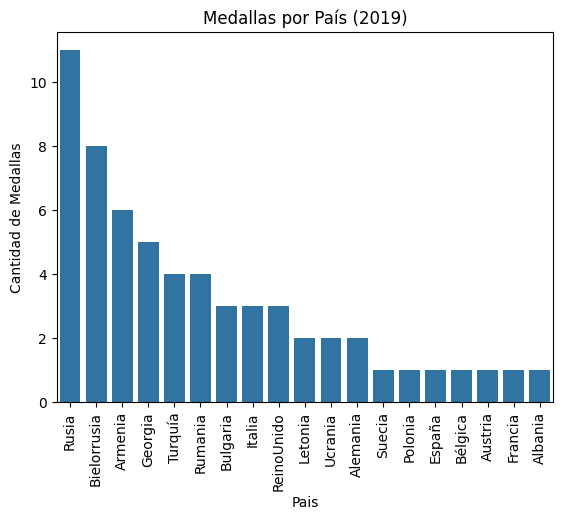

In [30]:
#gráficamente: medallas totales
conteo = tabla_ordenada2["Pais"].value_counts()
sns.countplot(data=tabla_ordenada2, x="Pais", order=conteo.index)
plt.xticks(rotation=90)  # gira los nombres de países si se superponen
plt.ylabel("Cantidad de Medallas")
plt.title("Medallas por País (2019)")
plt.show()

Rusia es el país que más medallas ha conseguido en total en 2019. Por el contrario, Suecia, Polonia, España, Bélgica, Austria, Francia y Albania son los países que menos medallas han conseguido ese año, sólo una medalla respectivamente

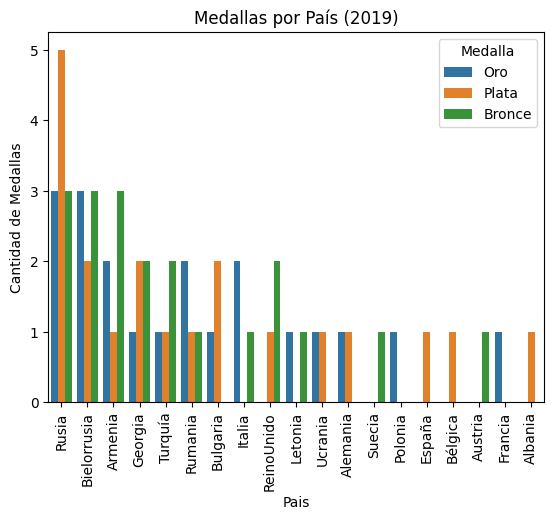

In [31]:
#gráficamente: por tipo de medalla
conteo = tabla_ordenada2["Pais"].value_counts()
sns.countplot(data=tabla_ordenada2, x="Pais", hue="Medalla", order=conteo.index)
plt.xticks(rotation=90)  # gira los nombres de países si se superponen
plt.ylabel("Cantidad de Medallas")
plt.title("Medallas por País (2019)")
plt.show()

Rusia ha ganado con diferencia más medallas de plata. En oros va empatado con Bielorrusia. Y en bronce con Bielorrusia y Armenia. Suecia, Polonia, España, Bélgica, Austria, Francia y Andorra sólo han conseguido un tipo de medalla

In [32]:
# Pregunta clave 2: ¿Qué país ha logrado mayor equidad en el éxito entre sus atletas femeninos y masculinos?
pc2=tabla_ordenada2.groupby(["Pais", "Género"]).size().unstack() #no incluyo el tipo de medalla 
pc2["Equidad"] = pc2.min(axis=1) / pc2.max(axis=1) #así vemos la relación entre el valor máximo de medallas ganadas


In [33]:
pc2

Género,Femenino,Masculino,Equidad
Pais,,,
Albania,NaN,1.0,1.000000
Alemania,1.0,1.0,1.000000
Armenia,1.0,5.0,0.200000
Austria,1.0,NaN,1.000000
Bielorrusia,2.0,6.0,0.333333
Bulgaria,1.0,2.0,0.500000
Bélgica,1.0,NaN,1.000000
España,1.0,NaN,1.000000
Francia,NaN,1.0,1.000000


<Axes: xlabel='Pais'>

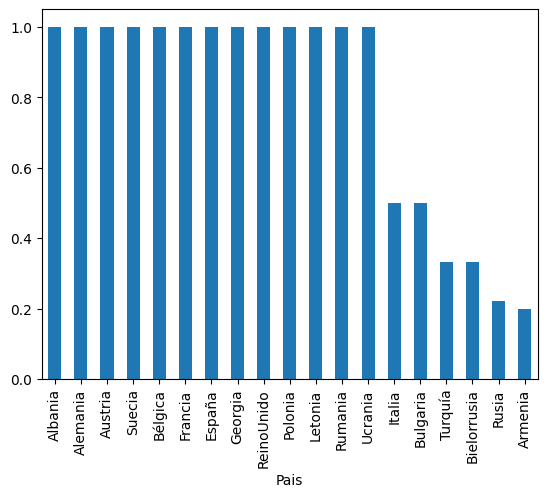

In [34]:
pc2["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

<Axes: xlabel='Pais'>

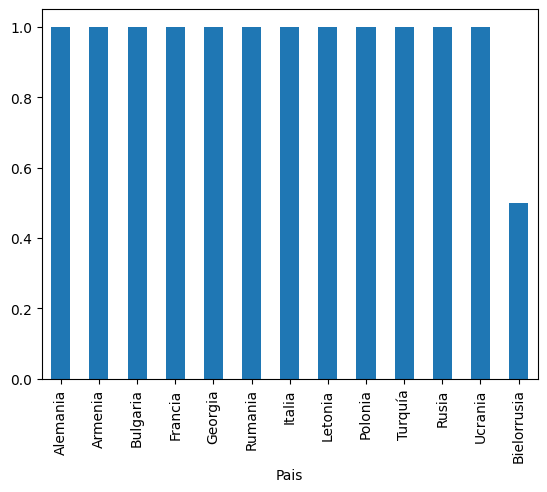

In [35]:
#si lo queremos hacer por tipo de medalla: Oro
pc_oro = tabla_ordenada2[tabla_ordenada2["Medalla"] == "Oro"]
pc2_oro=pc_oro.groupby(["Pais", "Género"]).size().unstack() 
pc2_oro["Equidad"] = pc2_oro.min(axis=1) / pc2_oro.max(axis=1)
pc2_oro["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

<Axes: xlabel='Pais'>

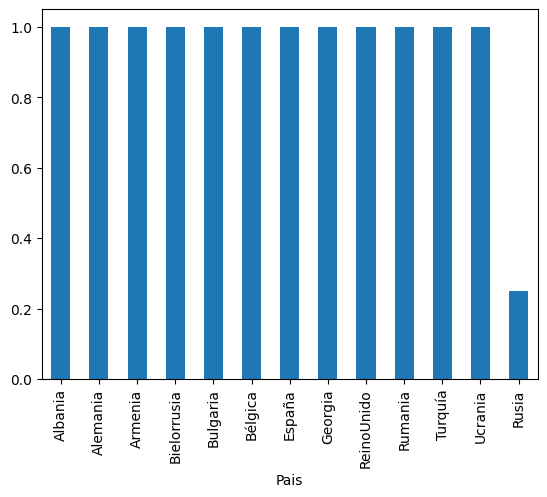

In [36]:
#si lo queremos hacer por tipo de medalla: Plata
pc_plata = tabla_ordenada2[tabla_ordenada2["Medalla"] == "Plata"]
pc2_plata=pc_plata.groupby(["Pais", "Género"]).size().unstack() 
pc2_plata["Equidad"] = pc2_plata.min(axis=1) / pc2_plata.max(axis=1)
pc2_plata["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

<Axes: xlabel='Pais'>

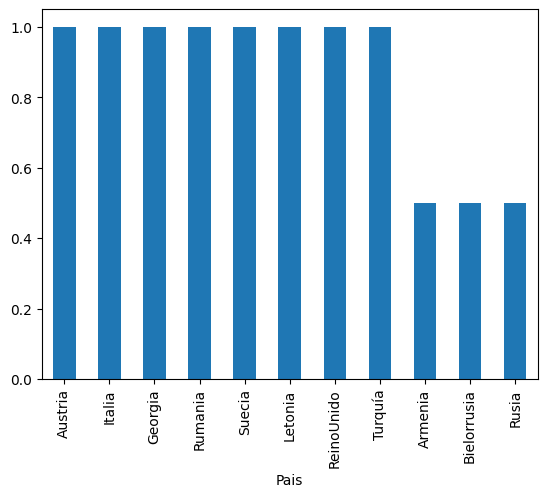

In [37]:
#si lo queremos hacer por tipo de medalla: Bronce
pc_bronce = tabla_ordenada2[tabla_ordenada2["Medalla"] == "Bronce"]
pc2_bronce=pc_bronce.groupby(["Pais", "Género"]).size().unstack() 
pc2_bronce["Equidad"] = pc2_bronce.min(axis=1) / pc2_bronce.max(axis=1)
pc2_bronce["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

Los países donde hay menos equidad son Armenia, Bielorrusia y Rusia, especialmente en medallas de Bronce. Si consideramos la equidad en el total de medallas Italia, Bulgaria y Turquía tampoco tienen equidad de género. El resto, sí.

In [38]:
tabla_ordenada2.head()

,Género,Año,Medalla,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total,Categoria,Fecha
0,Femenino,2019,Oro,Şaziye,Erdoğan,Turquía,75,88,163​,45 kg,06.04
1,Femenino,2019,Plata,Ivana,Petrova,Bulgaria,69,89,158​,45 kg,06.04
2,Femenino,2019,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150​,45 kg,06.04
3,Femenino,2019,Oro,Elena,Andrieș,Rumania,87,103,190,49 kg,06.04
4,Femenino,2019,Plata,Kristina,Sobol,Rusia,85,95,180,49 kg,06.04


In [39]:
# Pregunta clave 3: ¿Qué país muestra menor diferencia en el promedio de puntos totales obtenidos entre atletas femeninos y masculinos?
tabla_ordenada2["Total"] = pd.to_numeric(tabla_ordenada2["Total"], errors="coerce") #pasar la variable a numérica, porque estaba en string
peso_medio19 = tabla_ordenada2.groupby(["Pais", "Género"])["Total"].mean()
peso_medio19 #ok

Pais         Género   
Albania      Masculino    339.000000
Alemania     Femenino     222.000000
             Masculino    311.000000
Armenia      Femenino     217.000000
             Masculino    395.000000
Austria      Femenino     231.000000
Bielorrusia  Femenino     242.000000
             Masculino    360.500000
Bulgaria     Femenino            NaN
             Masculino    345.000000
Bélgica      Femenino     221.000000
España       Femenino     241.000000
Francia      Masculino    312.000000
Georgia      Masculino    396.000000
Italia       Femenino     178.000000
             Masculino    356.000000
Letonia      Femenino     221.000000
             Masculino    354.000000
Polonia      Femenino     199.000000
ReinoUnido   Femenino     233.333333
Rumania      Femenino     218.250000
Rusia        Femenino     227.555556
             Masculino    394.000000
Suecia       Femenino     233.000000
Turquía      Femenino            NaN
             Masculino    282.500000
Ucrania      Fe

In [40]:
#ahora calculamos la diferencia entre géneros por país
peso_medio19_dif=peso_medio19.unstack()
peso_medio19_dif["Diferencia"] = (peso_medio19_dif["Masculino"] - peso_medio19_dif["Femenino"]). abs() #en valores absolutos
peso_medio19_dif_ordenado = peso_medio19_dif.sort_values("Diferencia") #ordenamos de menor a mayor diferencia
peso_medio19_dif_ordenado #en los casos que aparece NaN es porque no hay medallistas femeninos o masculinos (missing data)

Género,Femenino,Masculino,Diferencia
Pais,,,
Alemania,222.000000,311.0,89.000000
Bielorrusia,242.000000,360.5,118.500000
Ucrania,268.000000,391.0,123.000000
Letonia,221.000000,354.0,133.000000
Rusia,227.555556,394.0,166.444444
Armenia,217.000000,395.0,178.000000
Italia,178.000000,356.0,178.000000
Albania,NaN,339.0,NaN
Austria,231.000000,NaN,NaN


In [41]:
peso_medio19_dif_ordenado = peso_medio19_dif_ordenado.dropna(subset=["Diferencia"]) #eliminamos los NaN
peso_medio19_dif_ordenado #ok

Género,Femenino,Masculino,Diferencia
Pais,,,
Alemania,222.000000,311.0,89.000000
Bielorrusia,242.000000,360.5,118.500000
Ucrania,268.000000,391.0,123.000000
Letonia,221.000000,354.0,133.000000
Rusia,227.555556,394.0,166.444444
Armenia,217.000000,395.0,178.000000
Italia,178.000000,356.0,178.000000


<Axes: xlabel='Pais'>

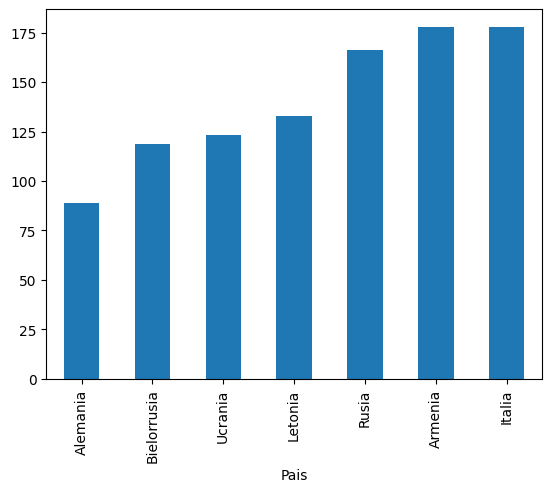

In [42]:
#gráficamente
peso_medio19_dif_ordenado["Diferencia"].sort_values(ascending=True).plot(kind="bar", stacked=True)

En 2019 Alemania es el país que menos diferencia mostró en promedio de puntos totales entre atletas de ambos sexos

FASE 2: Web scraping y análisis con datos ampliados (2019-2024)

1. Obtención de datos adicionales


In [43]:
# Obtención de los datos del Campeonato de Halterofilia de 2021-2024

urls = {
    2021: "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2021",
    2022: "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2022",
    2023: "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2023",
    2024: "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2024"
}

# Diccionarios para guardar dfs
masculino = {}
femenino= {}
total = {}

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

for year, url in urls.items():
    html = requests.get(url, headers=headers).text 

    tables = pd.read_html(html) #extrae todas las tablas

    # Quedarnos sólo con las tablas que nos interesan(medallistas)
    masculino[year] = tables[2] 
    femenino[year] = tables[3]

     # añadir columna con el año
    masculino[year]["Año"]=year
    femenino[year]["Año"]=year

     # añadir columna con el género
    masculino[year]["Género"]="Femenino"
    femenino[year]["Género"]="Masculino"

     # crear tablas totales (masculino y femenino)
    total[year]={}
    total[year] = pd.concat([masculino[year], femenino[year]], ignore_index=True)

C:\Users\amour1\AppData\Local\Temp\ipykernel_20356\424155608.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html) #extrae todas las tablas
C:\Users\amour1\AppData\Local\Temp\ipykernel_20356\424155608.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html) #extrae todas las tablas
C:\Users\amour1\AppData\Local\Temp\ipykernel_20356\424155608.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html) #extrae todas las tablas
C:\Users\amour1\AppData\Local\Temp\ipykernel_20356\424155608.py:20: FutureWarning: Passing literal html to 'read_html' is de

In [44]:
#comprobación 
total[2021] #ok

,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Año,Género
0,55 kg (04.04),Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Valentin Iancu Rumania 108 + 140 = 248[n 1]​,Dmytro Voronovsky Ucrania 110 + 137 = 247[n 1]​,2021,Femenino
1,61 kg (04.04),Stilian Grozdev Bulgaria 136 + 160 = 296,Shota Mishvelidze Georgia 135 + 155 = 290,Ferdi Hardal Turquía 130 + 157 = 287,2021,Femenino
2,67 kg (05.04),Muhammed Özbek Turquía 145 + 178 = 323,Mirko Zanni Italia 148 + 170 = 318,Valentin Guenchev Bulgaria 138 + 177 = 315,2021,Femenino
3,73 kg (06.04),Daniyar İsmayilov Turquía 160 + 181 = 341,Marin Robu Moldavia 156 + 183 = 339,Briken Calja Albania 152 + 184 = 336,2021,Femenino
4,81 kg (07.04),Antonino Pizzolato Italia 164 + 206 = 370,Karlos Nasar Bulgaria 163 + 206 = 369,Ritvars Suharevs Letonia 157 + 190 = 347,2021,Femenino
5,89 kg (08.04),Karen Avaguian Armenia 175 + 200 = 375,Revaz Davitadze Georgia 171 + 203 = 374,Andranik Karapetian Armenia 170 + 195 = 365,2021,Femenino
6,96 kg (09.04),Anton Pliesnoi Georgia 180 + 213 = 393,Piotr Asayonak Bielorrusia 172 + 202 = 374,Hakob Mkrtchian Armenia 160 + 212 = 372,2021,Femenino
7,102 kg (10.04),Samvel Gasparian Armenia 176 +214 = 390,Arsen Martirosian Armenia 171 + 209 = 380,Dadaş Dadaşbəyli Azerbaiyán 177 + 202 = 379,2021,Femenino
8,109 kg (10.04),Dmytro Chumak Ucrania 181 + 226 = 407,Jristo Jristov Bulgaria 186 + 220 = 406,Timur Naniyev Rusia 184 + 217 = 401,2021,Femenino
9,+109 kg (11.04),Lasha Talajadze Georgia 222 + 263 = 485,Gor Minasian Armenia 216 + 248 = 464,Varazdat Lalayan Armenia 205 + 240 = 445,2021,Femenino


In [45]:
#Unir todas las tablas 2021-2024 en una sola
total21_24 = pd.concat([total[2021], total[2022], total[2023], total[2024]], ignore_index=True)

In [46]:
#comprobación
total21_24 #ok, 80 observaciones (10 masc + 10 fem * 4 años)

,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Año,Género
0,55 kg (04.04),Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Valentin Iancu Rumania 108 + 140 = 248[n 1]​,Dmytro Voronovsky Ucrania 110 + 137 = 247[n 1]​,2021,Femenino
1,61 kg (04.04),Stilian Grozdev Bulgaria 136 + 160 = 296,Shota Mishvelidze Georgia 135 + 155 = 290,Ferdi Hardal Turquía 130 + 157 = 287,2021,Femenino
2,67 kg (05.04),Muhammed Özbek Turquía 145 + 178 = 323,Mirko Zanni Italia 148 + 170 = 318,Valentin Guenchev Bulgaria 138 + 177 = 315,2021,Femenino
3,73 kg (06.04),Daniyar İsmayilov Turquía 160 + 181 = 341,Marin Robu Moldavia 156 + 183 = 339,Briken Calja Albania 152 + 184 = 336,2021,Femenino
4,81 kg (07.04),Antonino Pizzolato Italia 164 + 206 = 370,Karlos Nasar Bulgaria 163 + 206 = 369,Ritvars Suharevs Letonia 157 + 190 = 347,2021,Femenino
...,...,...,...,...,...,...
75,71 kg (16.02),Loredana Toma Rumania 114 + 127 = 241,Siuzanna Valodzka AIN[a 1]​ 105 + 130 = 235,Lisa Marie Schweizer Alemania 107 + 124 = 231,2024,Masculino
76,76 kg (17.02),Genna Toko Kegne Italia 101 + 120 = 221,Nikol Rubanovich Israel 99 + 117 = 216,Lara Dancz Alemania 101 + 114 = 215,2024,Masculino
77,81 kg (18.02),Weronika Zielińska-Stubińska Polonia 103 + 13...,Elena Erighina Moldavia 103+ 131 = 234,Dilara Narin Turquía 97 + 125 = 222,2024,Masculino
78,87 kg (19.02),Solfrid Koanda Noruega 120 + 160 = 280,Anastasiya Manievska Ucrania 102 + 128 = 230,Hripsime Jurshudian Armenia 105 + 122 = 227,2024,Masculino


In [47]:
#añadimos medalla. Nota: cada columna de Unnamed pertenece al tipo de medalla (oro, plata, bronce) 
total21_24.insert(loc=1, column="Medalla Oro", value="Oro")  
total21_24.insert(loc=3, column="Medalla Plata", value="Plata")  
total21_24.insert(loc=5, column="Medalla Bronce", value="Bronce")  

In [48]:
#ordenemos la tabla que el tipo de medalla no esté en 3 columnas, si no en 1
total21_24_orden = pd.DataFrame({
    "Evento": total21_24["Evento"].tolist() * 3,
    "Género": total21_24["Género"].tolist() * 3,
    "Año": total21_24["Año"].tolist() * 3,
    "Atleta": (
        total21_24["Unnamed: 1"].tolist()
        + total21_24["Unnamed: 2"].tolist()
        + total21_24["Unnamed: 3"].tolist()
      ),
    "Medalla": (
        total21_24["Medalla Oro"].tolist()
        + total21_24["Medalla Plata"].tolist()
        + total21_24["Medalla Bronce"].tolist()
    )
})

In [49]:
total21_24_orden # ok, 80 filas x 3 tipos de medalla (oro, plata, bronce)

,Evento,Género,Año,Atleta,Medalla
0,55 kg (04.04),Femenino,2021,Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Oro
1,61 kg (04.04),Femenino,2021,Stilian Grozdev Bulgaria 136 + 160 = 296,Oro
2,67 kg (05.04),Femenino,2021,Muhammed Özbek Turquía 145 + 178 = 323,Oro
3,73 kg (06.04),Femenino,2021,Daniyar İsmayilov Turquía 160 + 181 = 341,Oro
4,81 kg (07.04),Femenino,2021,Antonino Pizzolato Italia 164 + 206 = 370,Oro
...,...,...,...,...,...
235,71 kg (16.02),Masculino,2024,Lisa Marie Schweizer Alemania 107 + 124 = 231,Bronce
236,76 kg (17.02),Masculino,2024,Lara Dancz Alemania 101 + 114 = 215,Bronce
237,81 kg (18.02),Masculino,2024,Dilara Narin Turquía 97 + 125 = 222,Bronce
238,87 kg (19.02),Masculino,2024,Hripsime Jurshudian Armenia 105 + 122 = 227,Bronce


2. Transformación y análisis: integra los datos obtenidos con los de 2019 y 2020, y responde nuevamente las preguntas clave para todo el periodo 2019-2024.

In [50]:
total2019_orden.head(3)

,Evento,Género,Año,Medalla,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total,Categoria,Fecha
0,55 kg (06.04),Masculino,2019,Oro,Mirco,Scarantino,Italia,116,145,261​,55 kg,06.04
1,61 kg (07.04),Masculino,2019,Oro,Henadz,Laptseu,Bielorrusia,133,153,286,61 kg,07.04
2,67 kg (08.04),Masculino,2019,Oro,Bernardin,Matam,Francia,137,175,312,67 kg,08.04


In [51]:
pd.set_option('display.max_rows', None) #para poder ver todas las filas
total21_24_orden

,Evento,Género,Año,Atleta,Medalla
0,55 kg (04.04),Femenino,2021,Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Oro
1,61 kg (04.04),Femenino,2021,Stilian Grozdev Bulgaria 136 + 160 = 296,Oro
2,67 kg (05.04),Femenino,2021,Muhammed Özbek Turquía 145 + 178 = 323,Oro
3,73 kg (06.04),Femenino,2021,Daniyar İsmayilov Turquía 160 + 181 = 341,Oro
4,81 kg (07.04),Femenino,2021,Antonino Pizzolato Italia 164 + 206 = 370,Oro
5,89 kg (08.04),Femenino,2021,Karen Avaguian Armenia 175 + 200 = 375,Oro
6,96 kg (09.04),Femenino,2021,Anton Pliesnoi Georgia 180 + 213 = 393,Oro
7,102 kg (10.04),Femenino,2021,Samvel Gasparian Armenia 176 +214 = 390,Oro
8,109 kg (10.04),Femenino,2021,Dmytro Chumak Ucrania 181 + 226 = 407,Oro
9,+109 kg (11.04),Femenino,2021,Lasha Talajadze Georgia 222 + 263 = 485,Oro


In [52]:
#limpieza de valores no necesarios (p. ej. [n 1])
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("[n 1]", "", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("[a 1]", "", regex=False)

In [53]:
#una forma fácil de ver dónde están los nombres o apellidos compuestos
df_split = total21_24_orden["Atleta"].str.split(expand=True) #separar atleta en varias sin limitar por nombre
df_split

,0,1,2,3,4,5,6,7,8
0,Anguel,Rusev,Bulgaria,111,+,147,=,258​,None
1,Stilian,Grozdev,Bulgaria,136,+,160,=,296,None
2,Muhammed,Özbek,Turquía,145,+,178,=,323,None
3,Daniyar,İsmayilov,Turquía,160,+,181,=,341,None
4,Antonino,Pizzolato,Italia,164,+,206,=,370,None
5,Karen,Avaguian,Armenia,175,+,200,=,375,None
6,Anton,Pliesnoi,Georgia,180,+,213,=,393,None
7,Samvel,Gasparian,Armenia,176,+214,=,390,None,None
8,Dmytro,Chumak,Ucrania,181,+,226,=,407,None
9,Lasha,Talajadze,Georgia,222,+,263,=,485,None


In [54]:
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("+214", "+ 214", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("117+", "117 +", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("103+", "103 +", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("+114", "+ 114", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("171+", " 171 +", regex=False)

total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Reyes Martínez", "Reyes-Martínez", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("García Rincón", "García-Rincón", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Ruiz Velasco", "Ruiz-Velasco", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Hernández Mendoza", "Hernández-Mendoza", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Sánchez López​", "Sánchez-López", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Mata Pérez", "Mata-Pérez", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Brachi García", "Brachi-García", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Lisa Marie", "Lisa-Marie", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Toko Kegne", "Toko-Kegne", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Han Yüksel", "Han-Yüksel", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Sánchez López", "Sánchez-López", regex=False)
total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Sol Anette", "Sol-Anette", regex=False)

total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.replace("Reino Unido", "ReinoUnido", regex=False)


In [55]:
#veamos cuántas columnas tiene cada fila porque no me dejaba aplicar los nombres, deberían ser 8
total21_24_orden["Atleta"].str.split(" ").apply(len).value_counts() #probablemente espacios en blanco

Atleta
9     239
10      1
Name: count, dtype: int64

In [56]:
longitudes = total21_24_orden["Atleta"].str.split(" ").apply(len)
filas_problema = total21_24_orden[longitudes != 9] #veamos cuál tiene más de 9
print(filas_problema["Atleta"])

total21_24_orden["Atleta"] = total21_24_orden["Atleta"].str.strip().str.replace(r"\s+", " ", regex=True) #quitamos espacios

225    Marin Robu Moldavia   171 + 207 = 378
Name: Atleta, dtype: object


In [57]:
#creo las variables adicionales a parte de los nombres y apellidos de los atletas, como en 2019
total21_24_orden[["Nombre", "Apellidos", "Pais", "Arrancada", "+", "Dos Tiempos", "=", "Total"]]= (total21_24_orden["Atleta"].str.split(" ", expand=True))

In [58]:
total21_24_orden.head()

,Evento,Género,Año,Atleta,Medalla,Nombre,Apellidos,Pais,Arrancada,+,Dos Tiempos,=,Total
0,55 kg (04.04),Femenino,2021,Anguel Rusev Bulgaria 111 + 147 = 258​,Oro,Anguel,Rusev,Bulgaria,111,+,147,=,258​
1,61 kg (04.04),Femenino,2021,Stilian Grozdev Bulgaria 136 + 160 = 296,Oro,Stilian,Grozdev,Bulgaria,136,+,160,=,296
2,67 kg (05.04),Femenino,2021,Muhammed Özbek Turquía 145 + 178 = 323,Oro,Muhammed,Özbek,Turquía,145,+,178,=,323
3,73 kg (06.04),Femenino,2021,Daniyar İsmayilov Turquía 160 + 181 = 341,Oro,Daniyar,İsmayilov,Turquía,160,+,181,=,341
4,81 kg (07.04),Femenino,2021,Antonino Pizzolato Italia 164 + 206 = 370,Oro,Antonino,Pizzolato,Italia,164,+,206,=,370


In [59]:
#eliminamos las variables no necesarias
total21_24_orden = total21_24_orden.drop(columns=["Atleta", "+", "="])

In [60]:
#creación de variables "Categoría" Y "Fecha" a partir de "Evento"
total21_24_orden[["Categoria", "Fecha"]] = total21_24_orden["Evento"].str.split(" ", expand=True)
total21_24_orden["Fecha"] = total21_24_orden["Fecha"].str.replace("(", "")
total21_24_orden["Fecha"] = total21_24_orden["Fecha"].str.replace(")", "")


In [61]:
total2019_orden.head(3)


,Evento,Género,Año,Medalla,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total,Categoria,Fecha
0,55 kg (06.04),Masculino,2019,Oro,Mirco,Scarantino,Italia,116,145,261​,55 kg,06.04
1,61 kg (07.04),Masculino,2019,Oro,Henadz,Laptseu,Bielorrusia,133,153,286,61 kg,07.04
2,67 kg (08.04),Masculino,2019,Oro,Bernardin,Matam,Francia,137,175,312,67 kg,08.04


In [62]:
#reordenar para que coincida con la de 2019
total21_24_orden = total21_24_orden[["Evento","Género", "Año", "Medalla", "Nombre", "Apellidos", "Pais", "Arrancada", "Dos Tiempos", "Total", "Categoria", "Fecha"]]



In [63]:
#unimos tablas de 2019 y 2021-2024
total_19_24_orden = pd.concat([total2019_orden, total21_24_orden], ignore_index=True)
total_19_24_orden = total_19_24_orden.drop(columns=["Evento"]) #redundante

In [64]:
#comprobación
total_19_24_orden.head(3) #ok

,Género,Año,Medalla,Nombre,Apellidos,Pais,Arrancada,Dos Tiempos,Total,Categoria,Fecha
0,Masculino,2019,Oro,Mirco,Scarantino,Italia,116,145,261​,55 kg,06.04
1,Masculino,2019,Oro,Henadz,Laptseu,Bielorrusia,133,153,286,61 kg,07.04
2,Masculino,2019,Oro,Bernardin,Matam,Francia,137,175,312,67 kg,08.04


In [65]:
#comprobación2
total_19_24_orden.info() #ok. 300 observaciones (10 masc + 10 fem * 5 años * 3 tipos de medallas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Género       300 non-null    object
 1   Año          300 non-null    object
 2   Medalla      300 non-null    object
 3   Nombre       300 non-null    object
 4   Apellidos    300 non-null    object
 5   Pais         300 non-null    object
 6   Arrancada    300 non-null    object
 7   Dos Tiempos  300 non-null    object
 8   Total        300 non-null    object
 9   Categoria    300 non-null    object
 10  Fecha        300 non-null    object
dtypes: object(11)
memory usage: 25.9+ KB


Preguntas Clave

In [66]:
# Pregunta clave 1: ¿Cuántas medallas de cada tipo (oro, plata y bronce) ha ganado cada país?
total_19_24_orden.groupby(["Pais", "Medalla"]).size()

Pais         Medalla
AIN​         Bronce      2
             Oro         1
             Plata       1
Albania      Bronce      1
             Oro         1
             Plata       2
Alemania     Bronce      3
             Oro         1
             Plata       3
Armenia      Bronce     17
             Oro        14
             Plata      13
Austria      Bronce      2
Azerbaiyán   Bronce      1
             Oro         2
Bielorrusia  Bronce      3
             Oro         3
             Plata       3
Bulgaria     Bronce      5
             Oro        15
             Plata       8
Bélgica      Bronce      2
             Plata       2
España       Bronce      5
             Plata       5
Finlandia    Bronce      1
Francia      Bronce      3
             Oro         4
             Plata       2
Georgia      Bronce      5
             Oro         6
             Plata      13
Irlanda      Bronce      1
Israel       Plata       1
Italia       Bronce      3
             Oro         8
       

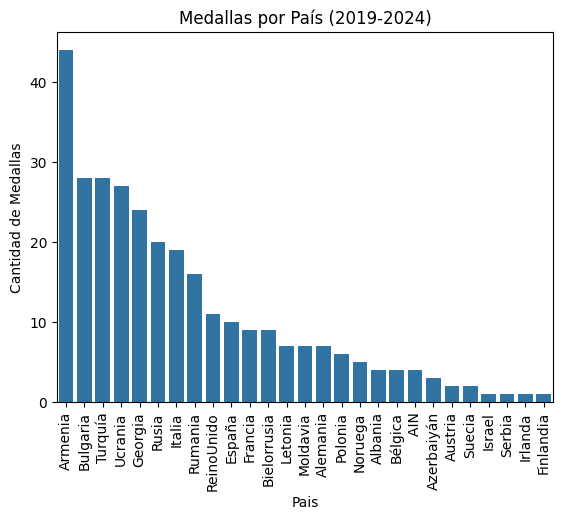

In [67]:
#gráficamente: medallas totales
conteo = total_19_24_orden["Pais"].value_counts()
sns.countplot(data=total_19_24_orden, x="Pais", order=conteo.index)
plt.xticks(rotation=90)  # gira los nombres de países si se superponen
plt.ylabel("Cantidad de Medallas")
plt.title("Medallas por País (2019-2024)")
plt.show()

Cuando miramos el total del periodo, Armenia es el país que más medallas ha conseguido. Ahora Rusia (campeón en 2019) está en 6º lugar. Israel, Serbia, Irlanda y Finlandia son los países que menos medallas han conseguido entre 2019 y 2024.

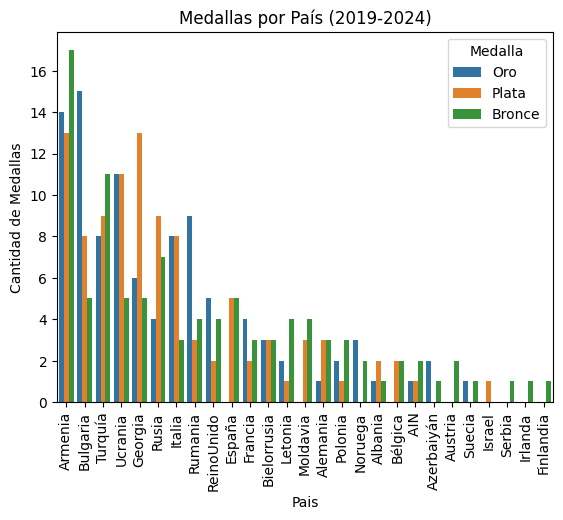

In [68]:
#gráficamente: por tipo de medalla
conteo = total_19_24_orden["Pais"].value_counts()
sns.countplot(data=total_19_24_orden, x="Pais", hue="Medalla", order=conteo.index)
plt.xticks(rotation=90)  # gira los nombres de países si se superponen
plt.ylabel("Cantidad de Medallas")
plt.title("Medallas por País (2019-2024)")
plt.show()

Cuando nos fijamos en el tipo de medalla, Armenia es la que más medallas de Oro y Bronce ha ganado, Georgia el que más medallas de plata.

In [69]:
# Pregunta clave 2: ¿Qué país ha logrado mayor equidad en el éxito entre sus atletas femeninos y masculinos?
pc_2=total_19_24_orden.groupby(["Pais", "Género"]).size().unstack() #no incluyo el tipo de medalla 
pc_2["Equidad"] = pc_2.min(axis=1) / pc_2.max(axis=1) #así vemos la relación entre el valor máximo de medallas ganadas
pc_2


Género,Femenino,Masculino,Equidad
Pais,,,
AIN​,3.0,1.0,0.333333
Albania,2.0,2.0,1.000000
Alemania,3.0,4.0,0.750000
Armenia,33.0,11.0,0.333333
Austria,1.0,1.0,1.000000
Azerbaiyán,2.0,1.0,0.500000
Bielorrusia,3.0,6.0,0.500000
Bulgaria,24.0,4.0,0.166667
Bélgica,1.0,3.0,0.333333


<Axes: xlabel='Pais'>

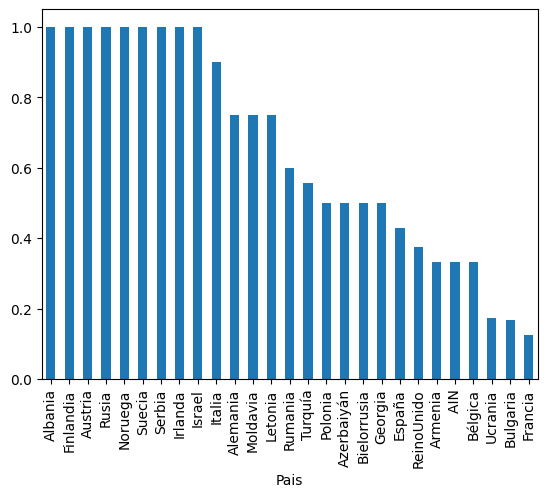

In [70]:
#gráficamente
pc_2["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

En este caso ya hay más inequidad entre países respecto a 2019. Sólo 9 países consiguen una equidad entre hombres y mujeres a la hora de ganar medallas de halterofilia

<Axes: xlabel='Pais'>

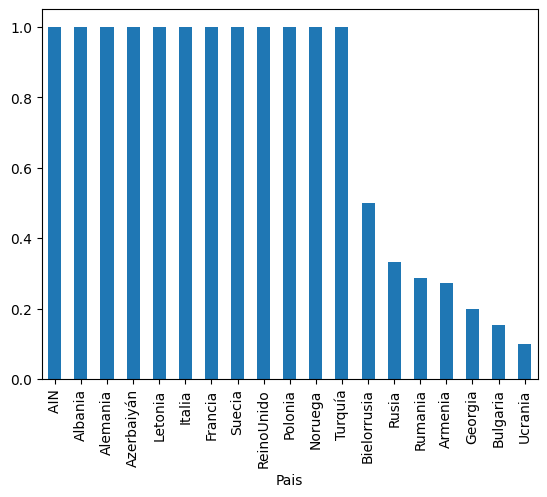

In [71]:
#si lo queremos hacer por tipo de medalla: Oro
pc1924_oro = total_19_24_orden[total_19_24_orden["Medalla"] == "Oro"]
pc2_1924_oro=pc1924_oro.groupby(["Pais", "Género"]).size().unstack() 
pc2_1924_oro["Equidad"] = pc2_1924_oro.min(axis=1) / pc2_1924_oro.max(axis=1)
pc2_1924_oro["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

Ucrania es el país con menos equidad en medallas de oro

<Axes: xlabel='Pais'>

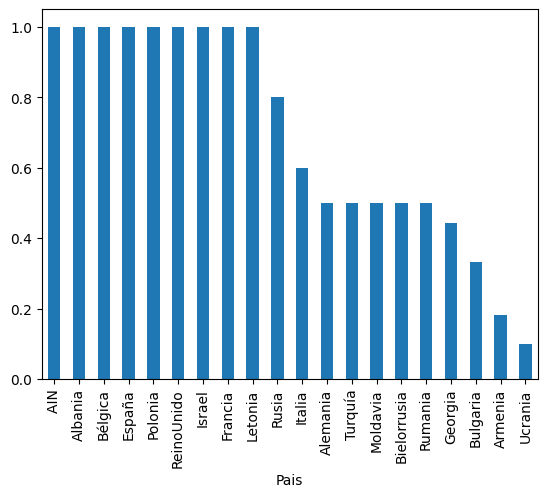

In [72]:
#si lo queremos hacer por tipo de medalla: Plata
pc1924_plata = total_19_24_orden[total_19_24_orden["Medalla"] == "Plata"]
pc2_1924_plata=pc1924_plata.groupby(["Pais", "Género"]).size().unstack() 
pc2_1924_plata["Equidad"] = pc2_1924_plata.min(axis=1) / pc2_1924_plata.max(axis=1)
pc2_1924_plata["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

De nuevo, Ucrania es el país con menos equidad en medallas de plata

<Axes: xlabel='Pais'>

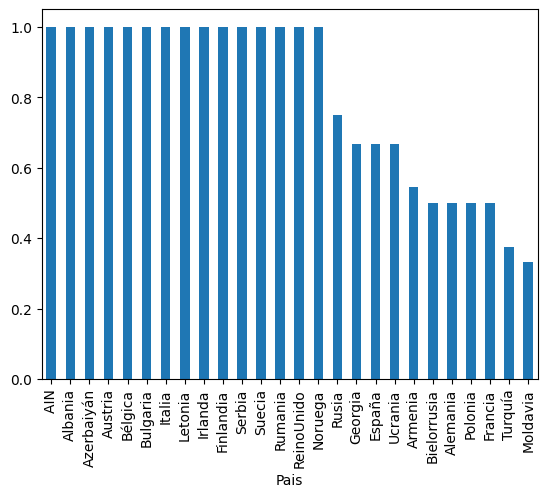

In [73]:
#si lo queremos hacer por tipo de medalla: Bronce
pc1924_bronce = total_19_24_orden[total_19_24_orden["Medalla"] == "Bronce"]
pc2_1924_bronce=pc1924_bronce.groupby(["Pais", "Género"]).size().unstack() 
pc2_1924_bronce["Equidad"] = pc2_1924_bronce.min(axis=1) / pc2_1924_bronce.max(axis=1)
pc2_1924_bronce["Equidad"].sort_values(ascending=False).plot(kind="bar", stacked=True)

En este caso, Moldavia es el país con menos equidad en medallas de bronce

In [74]:
# Pregunta clave 3: ¿Qué país muestra menor diferencia en el promedio de puntos totales obtenidos entre atletas femeninos y masculinos?
total_19_24_orden["Total"] = pd.to_numeric(total_19_24_orden["Total"], errors="coerce") #pasar la variable a numérica, porque estaba en string
peso_medio19_24 = total_19_24_orden.groupby(["Pais", "Género"])["Total"].mean()
peso_medio19_24 #ok

Pais         Género   
AIN​         Femenino     398.000000
             Masculino    235.000000
Albania      Femenino     338.500000
             Masculino    273.500000
Alemania     Femenino     295.333333
             Masculino    245.000000
Armenia      Femenino     384.545455
             Masculino    297.636364
Austria      Femenino     231.000000
             Masculino    230.000000
Azerbaiyán   Femenino     383.500000
             Masculino    211.000000
Bielorrusia  Femenino     308.000000
             Masculino    360.500000
Bulgaria     Femenino     340.277778
             Masculino    345.000000
Bélgica      Femenino     221.000000
             Masculino    203.666667
España       Femenino     318.333333
             Masculino    163.000000
Finlandia    Masculino    214.000000
Francia      Femenino     370.000000
             Masculino    235.875000
Georgia      Femenino     371.571429
             Masculino    340.500000
Irlanda      Masculino    169.000000
Israel       Ma

In [75]:
#ahora calculamos la diferencia entre géneros por país
peso_medio19_24_dif=peso_medio19_24.unstack()
peso_medio19_24_dif["Diferencia"] = (peso_medio19_24_dif["Masculino"] - peso_medio19_24_dif["Femenino"]). abs() #en valores absolutos
peso_medio19_24_dif_ordenado = peso_medio19_24_dif.sort_values("Diferencia") #ordenamos de menor a mayor diferencia
peso_medio19_24_dif_ordenado #en los casos que aparece NaN es porque no hay medallistas femeninos o masculinos (missing data)

Género,Femenino,Masculino,Diferencia
Pais,,,
Austria,231.000000,230.000000,1.000000
Bulgaria,340.277778,345.000000,4.722222
Rumania,218.250000,212.222222,6.027778
Suecia,233.000000,224.000000,9.000000
ReinoUnido,233.333333,245.000000,11.666667
Rusia,244.900000,257.600000,12.700000
Bélgica,221.000000,203.666667,17.333333
Georgia,371.571429,340.500000,31.071429
Letonia,308.750000,266.000000,42.750000


In [76]:
peso_medio19_24_dif_ordenado = peso_medio19_24_dif_ordenado.dropna(subset=["Diferencia"]) #eliminamos los NaN
peso_medio19_24_dif_ordenado #ok

Género,Femenino,Masculino,Diferencia
Pais,,,
Austria,231.000000,230.000000,1.000000
Bulgaria,340.277778,345.000000,4.722222
Rumania,218.250000,212.222222,6.027778
Suecia,233.000000,224.000000,9.000000
ReinoUnido,233.333333,245.000000,11.666667
Rusia,244.900000,257.600000,12.700000
Bélgica,221.000000,203.666667,17.333333
Georgia,371.571429,340.500000,31.071429
Letonia,308.750000,266.000000,42.750000


<Axes: xlabel='Pais'>

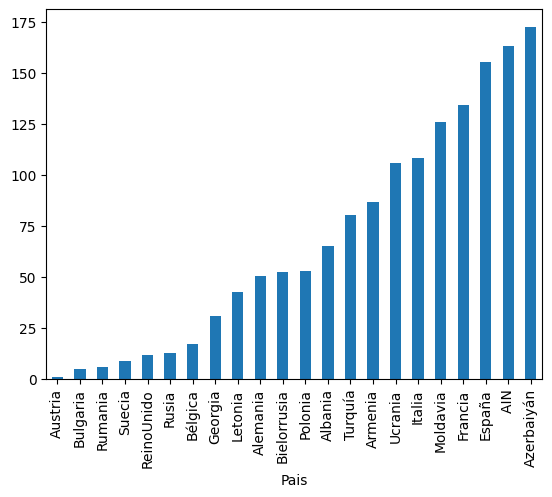

In [77]:
#gráficamente
peso_medio19_24_dif_ordenado["Diferencia"].sort_values(ascending=True).plot(kind="bar", stacked=True)

En el total del periodo 2019-2024 Austria es el país con menor diferencia en promedio de puntos totales entre ambos géneros. 

Como conclusión final, y dado el aumento de países presentados al Campeonato de Halterofilia respecto a 2019 podemos afirmar que hay un interés creciente por esta disciplina. Por lo tanto, aconsejamos invertir en centros dedicados exclusivamente a la Halterofilia en Europa

** fin del análisis **